#### This ML Model predicts the start station level demand for bikes. The same can be conducted to predict the end station level demand for bikes. The goal is to identify stations with capacity surplus or deficit in order to develop a strategy to equalize a potential disequilibrium within Capital BikeShares Washington DC bike sharing eco system in order to improve the overall performance.

### Load Packages and Dataset

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats
from sklearn.preprocessing import OneHotEncoder

start_station_daily = pd.read_csv("start_station_daily.csv", sep=',')

### Define Test/Training Set

In [ ]:
X = start_station_daily[[
    'start_lat',
    'start_lng',
    'start_station_id',
    'day',
    'month',
    # 'rental_length', 
    # 'trip_distance_km', 
    'mean_apparent_temperature/day',
    'mean_windspeed/day', 
    'mean_relative_humidity/day', 
    # 'weather_label/day',
    'season',
    'is_weekend', 
    'holiday',
    'total_rides/day_station_yesterday',
    'day_of_week',
    'avg_usage',
    'station_density_1km',
    'popularity_rank',
    'ward',
    'total_rides/day_station_weekago',
    'elevation',
    'is_special_event'
]]

y = start_station_daily['total_rides/day_station']

### Create Pipeline for TimeSeriesSplit, Transformation, Preprocessing, GridSearch and Model Evaluation

C:\Users\jakob\AppData\Local\Temp\ipykernel_8484\2213691269.py:77: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=feat_imp_df.head(10), x='importance', y='feature', palette='viridis')


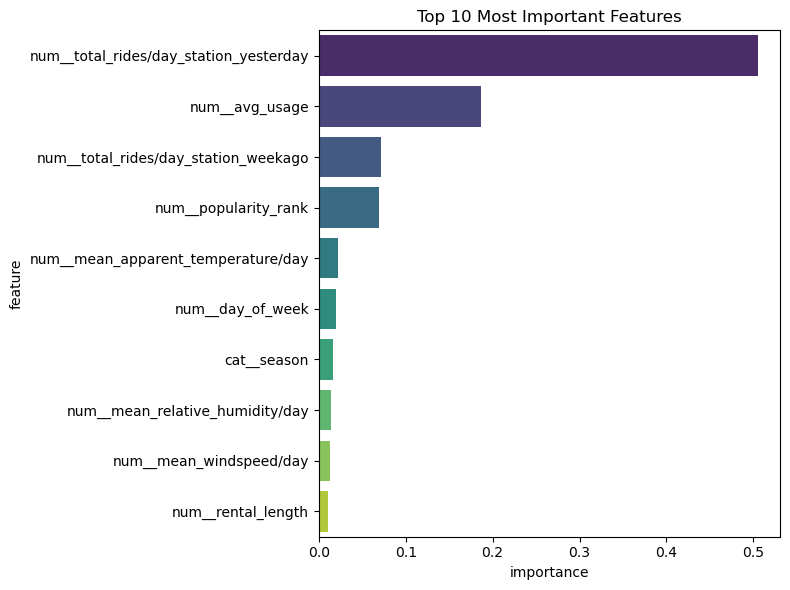

Split RMSE: 11.56
Split R²: 0.80
Best hyperparameters found: {'regressor__colsample_bytree': 0.96, 'regressor__learning_rate': 0.06, 'regressor__max_depth': 12, 'regressor__n_estimators': 360, 'regressor__subsample': 0.64}


C:\Users\jakob\AppData\Local\Temp\ipykernel_8484\2213691269.py:77: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=feat_imp_df.head(10), x='importance', y='feature', palette='viridis')


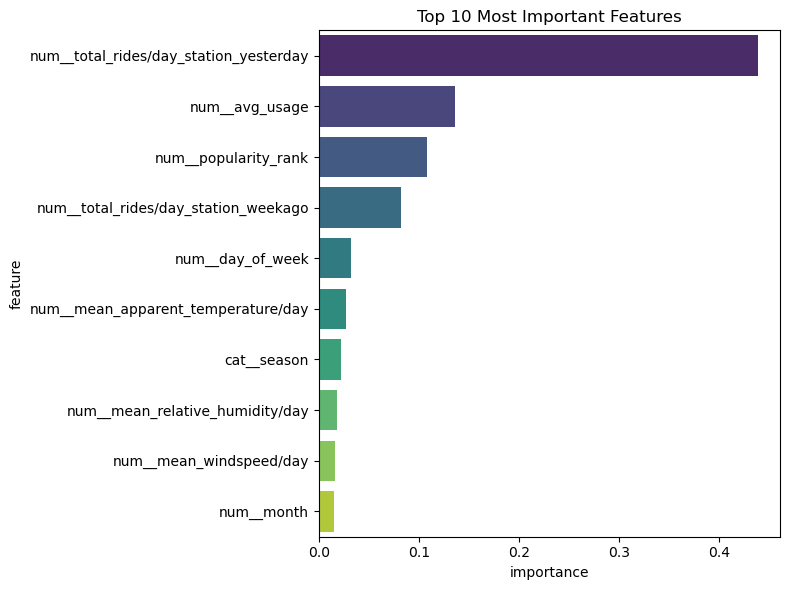

Split RMSE: 8.27
Split R²: 0.88
Best hyperparameters found: {'regressor__colsample_bytree': 0.96, 'regressor__learning_rate': 0.06, 'regressor__max_depth': 12, 'regressor__n_estimators': 360, 'regressor__subsample': 0.64}


C:\Users\jakob\AppData\Local\Temp\ipykernel_8484\2213691269.py:77: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=feat_imp_df.head(10), x='importance', y='feature', palette='viridis')


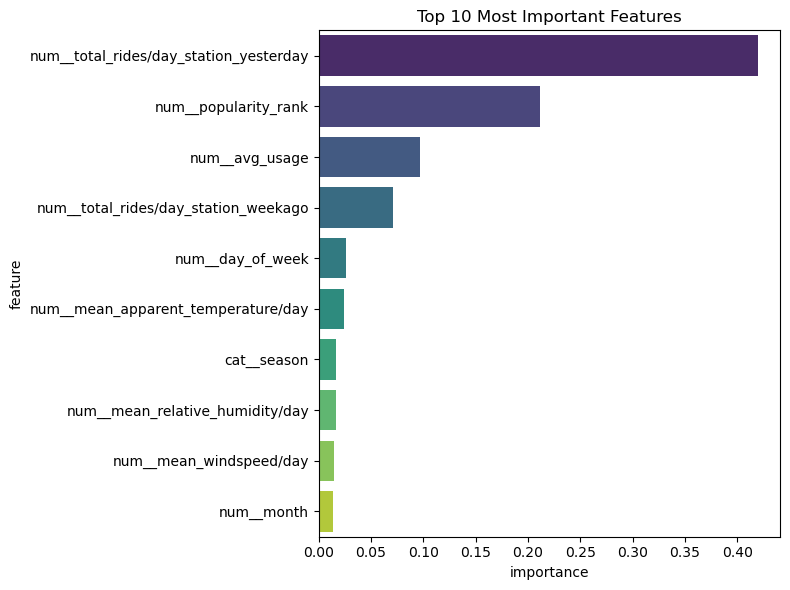

Split RMSE: 2.28
Split R²: 0.76
Best hyperparameters found: {'regressor__colsample_bytree': 0.96, 'regressor__learning_rate': 0.06, 'regressor__max_depth': 12, 'regressor__n_estimators': 360, 'regressor__subsample': 0.64}


In [5]:
from sklearn.model_selection import TimeSeriesSplit
from xgboost import XGBRegressor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OrdinalEncoder
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.compose import make_column_selector as selector

tscv = TimeSeriesSplit(n_splits=3)
all_results = []

for train_index, test_index in tscv.split(X):
    X_train, X_test = X.iloc[train_index], X.iloc[test_index]
    y_train, y_test = y.iloc[train_index], y.iloc[test_index]

    # Define transformers
    numeric_transformer = Pipeline(steps=[
        ('scaler', StandardScaler())
    ])
    categorical_transformer = Pipeline(steps=[
        ('ordinal', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1))
    ])

    preprocessor = ColumnTransformer(
        transformers=[
            ('num', numeric_transformer, selector(dtype_include=['int64', 'float64'])),
            ('cat', categorical_transformer, selector(dtype_include=['object', 'category']))
        ]
    )

    # Create pipeline with XGBRegressor
    pipeline = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('regressor', XGBRegressor(
            objective='reg:squarederror',
            random_state=42,
            n_jobs=-1,
            verbosity=0
        ))
    ])

    # Grid Search Parameter Grid
    param_grid = {
        'regressor__learning_rate': [0.06],
        'regressor__max_depth': [12],
        'regressor__n_estimators': [360],
        'regressor__subsample': [0.64],
        'regressor__colsample_bytree': [0.96]
    }


    grid_search = GridSearchCV(
        estimator=pipeline,
        param_grid=param_grid,
        cv=2,
        scoring='neg_mean_squared_error',
        verbose=0,
        n_jobs=-1
    )

    # Fit model
    grid_search.fit(X_train, y_train)
    best_model = grid_search.best_estimator_

    # Feature Importance
    importances = best_model.named_steps['regressor'].feature_importances_
    feature_names = best_model.named_steps['preprocessor'].get_feature_names_out()

    feat_imp_df = pd.DataFrame({
        'feature': feature_names,
        'importance': importances
    }).sort_values(by='importance', ascending=False)

    # Optional: Plot
    plt.figure(figsize=(8, 6))
    sns.barplot(data=feat_imp_df.head(10), x='importance', y='feature', palette='viridis')
    plt.title('Top 10 Most Important Features')
    plt.tight_layout()
    plt.show()

    # Predict on test set
    y_pred = best_model.predict(X_test)

    # Print GridSearchCV results for this split
    mse = mean_squared_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    print(f"Split RMSE: {mse ** 0.5:.2f}")
    print(f"Split R²: {r2:.2f}")
    print("Best hyperparameters found:", grid_search.best_params_)

    # Collect results for this split
    temp_df = pd.DataFrame({
        'date': start_station_daily.loc[y_test.index, 'date'],
        'actual': y_test,
        'predicted': y_pred,
        'residual': y_test - y_pred
    })
    all_results.append(temp_df)

# After the loop, concatenate all results
results_df = pd.concat(all_results, ignore_index=True)

### Evaluate Train/Test Set Size

In [4]:
for i, (train_index, test_index) in enumerate(tscv.split(X)):
    print(f"Split {i+1}: Train size={len(train_index)}, Test size={len(test_index)}")

Split 1: Train size=52544, Test size=52543
Split 2: Train size=105087, Test size=52543
Split 3: Train size=157630, Test size=52543


### Generate CSV Output with Predictions, Actuals and Residuals per Station per Day

In [ ]:
# Model Result Data Frame with 'date', 'actual', 'predicted', 'residual' for each test set row.

# To add the station ID to the output, merge with start_station_daily:
model_results = model_results.merge(
    start_station_daily[['date', 'start_station_id']],
    on='date',
    how='left'
)

# Optionally, reorder columns for clarity
model_results = model_results[['date', 'start_station_id', 'actual', 'predicted', 'residual']]

# Save to CSV
model_results.to_csv('predicted_station_demand_per_day.csv', index=False)